# Aula 7: X do SARIMAX, Auto ARIMA

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
from funcoes import all_ac, plot_forecast, teste_estacionariedade, diagnostico, compara_previsoes, correlacao_cruzada
plt.rcParams["figure.figsize"] = [12, 5]
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
df = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/clicks_original.csv')
df.index = pd.to_datetime(df['date'])
df = df.drop(['date'], axis=1)
df.index.freq = 'D'
df

/var/folders/f1/tdh3lyp114g78tg5wv2t7g3m0000gn/T/ipykernel_13384/444394987.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df['date'])


,price,location,clicks
date,,,
2008-04-01,43.155647,2,18784
2008-04-02,43.079056,1,24738
2008-04-03,43.842609,2,15209
2008-04-04,43.312376,1,14018
2008-04-05,43.941176,1,11974
...,...,...,...
2008-08-09,44.182033,1,6716
2008-08-10,43.608260,1,9523
2008-08-11,43.553363,1,8881


In [4]:
y = df['clicks']
x = df['price']



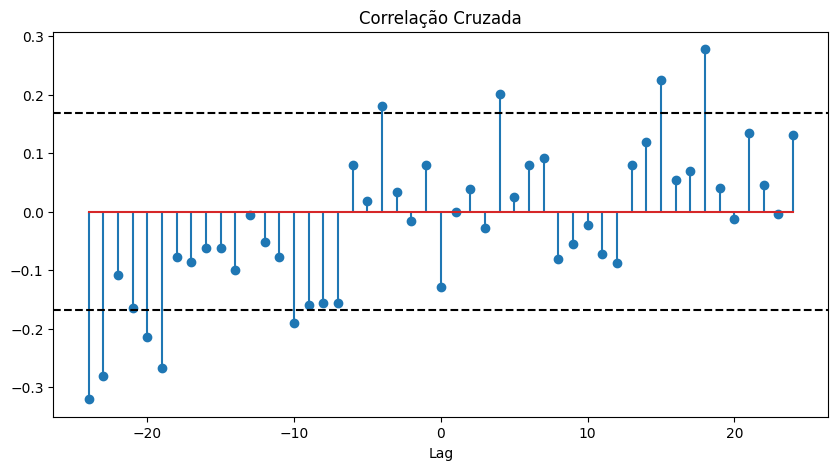

In [5]:
correlacao_cruzada(y,x)

In [4]:
model1 = SARIMAX(df['clicks'], order = (0,1,1), seasonal_order=(0,1,1,12), exog=df['price']).fit(disp=False)

/Users/danielferreira/miniconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [5]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             clicks   No. Observations:                  135
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1202.459
Date:                            Fri, 14 Mar 2025   AIC                           2412.917
Time:                                    20:07:33   BIC                           2424.134
Sample:                                04-01-2008   HQIC                          2417.473
                                     - 08-13-2008                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
price        243.5638     67.515      3.608      0.000     111.237     375.891
ma.L1         -0.9118      0.049    -18.666      0.000      -1.008      -0.816
ma.S.L12      -0.7856      0.120     -6.567      0.000      -1.020      -0.551
sigma2      2.028e+07      0.001    2.5e+10      0.000    2.03e+07    2.03e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                83.32
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.26   Skew:                             1.15
Prob(H) (two-sided):                  0.47   Kurtosis:                         6.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.48e+25. Standard errors may be unstable.
"""

In [6]:
preco_f = [45]*24

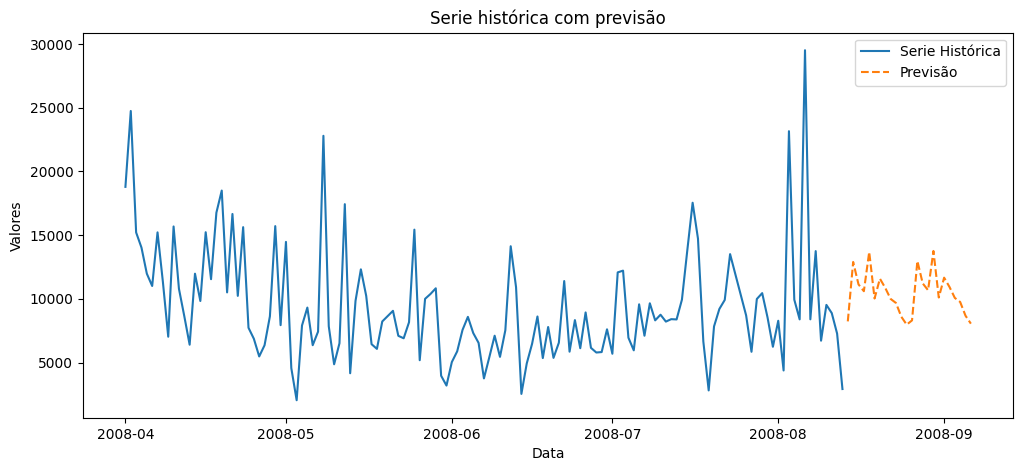

In [7]:
previsao1 = model1.get_forecast(steps=24, exog=preco_f).predicted_mean
plot_forecast(df['clicks'], previsao1)


In [8]:
df['price_4'] = df['price'].shift(4)
df = df.dropna()
model2 = SARIMAX(df['clicks'], order = (0,1,1), seasonal_order=(0,1,1,12), exog=df['price_4']).fit(disp=False)

/Users/danielferreira/miniconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                             clicks   No. Observations:                  131
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1160.743
Date:                            Fri, 14 Mar 2025   AIC                           2329.485
Time:                                    20:07:34   BIC                           2340.568
Sample:                                04-05-2008   HQIC                          2333.985
                                     - 08-13-2008                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
price_4      265.4741     75.870      3.499      0.000     116.771     414.177
ma.L1         -0.9082      0.051    -17.884      0.000      -1.008      -0.809
ma.S.L12      -0.8678      0.156     -5.546      0.000      -1.174      -0.561
sigma2      1.888e+07      0.000   9.41e+10      0.000    1.89e+07    1.89e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               125.35
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.32   Skew:                             1.40
Prob(H) (two-sided):                  0.39   Kurtosis:                         7.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.54e+26. Standard errors may be unstable.
"""

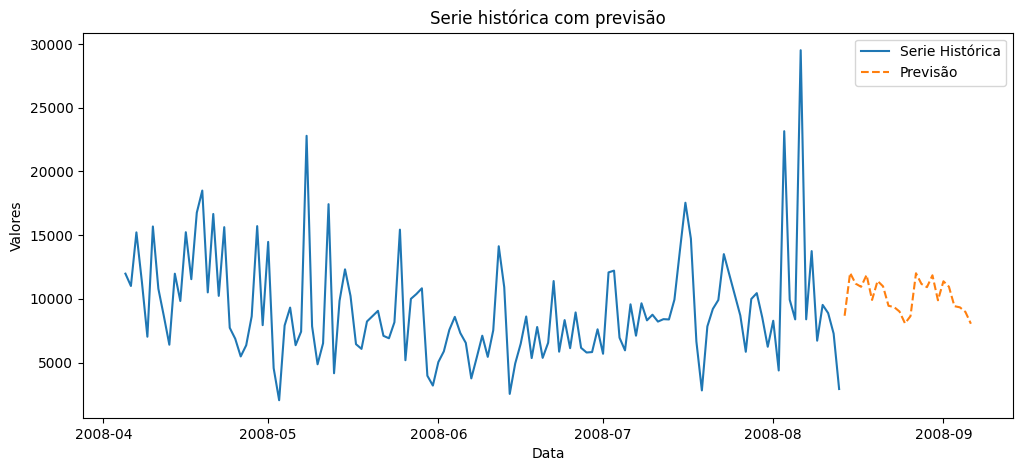

In [10]:
previsao2 = model2.get_forecast(steps=24, exog=preco_f).predicted_mean
plot_forecast(df['clicks'], previsao2)

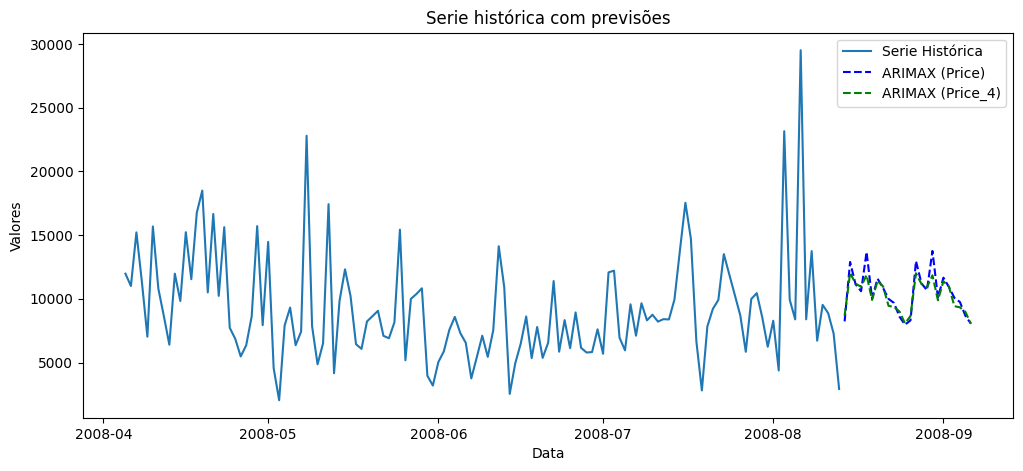

In [11]:
compara_previsoes(df['clicks'], [previsao1,previsao2], ['ARIMAX (Price)', 'ARIMAX (Price_4)'])

In [12]:
passos = 24
preco_medio = df['price'].mean()
preco_medio_f = [preco_medio]*passos
preco_min_f = [30]*passos


previsao1 = model1.get_forecast(steps=24, exog=preco_medio_f).predicted_mean
previsao2 = model1.get_forecast(steps=24, exog=preco_min_f).predicted_mean

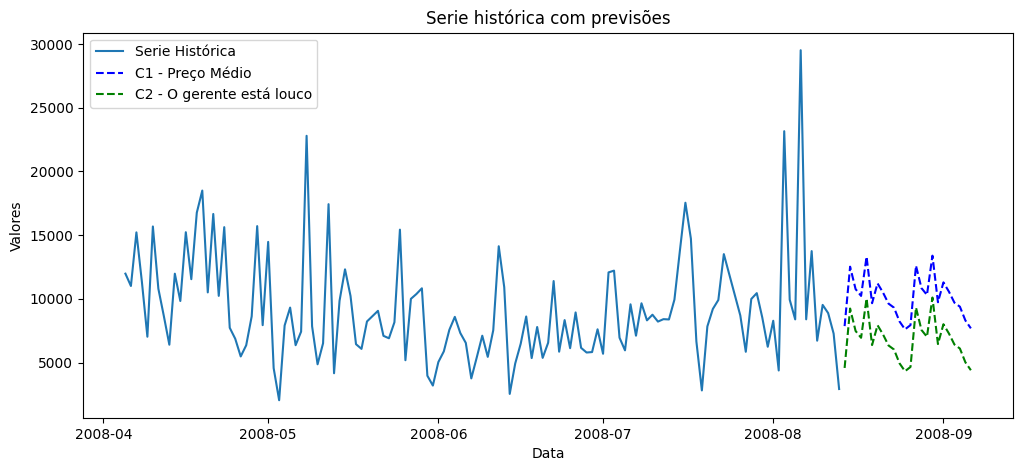

In [13]:
compara_previsoes(df['clicks'], [previsao1,previsao2], ['C1 - Preço Médio', 'C2 - O gerente está louco'])